# Ramen Rating Analysis

## Importing Libraries
To  begin the analysis, we import the core Python libraries used for data manipulation.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    silhouette_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("ramen-ratings.csv")

# Data Cleaning & Preprocessing

In [2]:
# Create a new column where Top Ten is a boolean
df['is_top_ten'] = df['Top Ten'].notna()

# Convert Stars column from str to float and set unrated ramen to 0.0
df['Stars'] = pd.to_numeric(df['Stars'], errors='coerce')
df['Stars'] = df['Stars'].fillna(0.0)

# Inspect missing Style values (optional check)
df[df['Style'].isna()]

# Replace missing Style values with "Unknown"
df['Style'] = df['Style'].fillna('Unknown')

# Create filtered dataset of rated ramen only
rated_df = df[df['Stars'] > 0]

# Create Top Ten subset
top_ten_df = df[df['is_top_ten'] == True]

# Prepare numeric-only correlation base
numeric_df = df[['Stars', 'is_top_ten']]

# Optional: One-hot encode Style and Country for extended correlation
df_encoded = pd.get_dummies(df[['Style', 'Country']], drop_first=True)
full_numeric = pd.concat([numeric_df, df_encoded], axis=1)

country_counts = df['Country'].value_counts()

# Keep only countries with at least 50 products
valid_countries = country_counts[country_counts >= 50].index


clean_df = df.copy()

clean_df['Style'] = (
    clean_df['Style']
    .fillna('Other')
    .str.strip()
    .str.title()
)

clean_df['Style'] = clean_df['Style'].replace({
    'Box': 'Other',
    'Can': 'Other',
    'Unknown': 'Other',
    'Bar': 'Other'
})

# Filter to valid countries
filtered_df = clean_df[clean_df['Country'].isin(valid_countries)]

# Remove "Other"
filtered_df = filtered_df[filtered_df['Style'] != 'Other']

# Pivot table for stacked bar chart
style_by_country = filtered_df.pivot_table(
    index='Country',
    columns='Style',
    values='Brand',
    aggfunc='count',
    fill_value=0
)

# Count totals for pie chart
style_totals_full = clean_df[clean_df['Style'] != 'Other']['Style'].value_counts()

# Colors for both charts
colors_bar = [
    "#1f77b4",  # Pack
    "#d62728",  # Bowl
    "#2ca02c",  # Cup
    "#9467bd"   # Tray
]

In [3]:
# Compute average ratings by country
country_avg = rated_df.groupby('Country')['Stars'].mean()

# Filter to countries with ≥ 50 products
filtered_country_avg = country_avg[country_avg.index.isin(valid_countries)]


### Filtering Countries by Sample Size

The initial analysis included all 38 countries in the dataset. However, many of these countries only had a handful of ramen products—some as few as one or two. This caused significant distortion in the average ratings, allowing small-sample outliers (such as Brazil and Fiji) to appear in the Top 10 despite having only 4–5 products each.

To correct for this, we applied a minimum threshold of **≥ 50 ramen products per country**. This ensures that the average ratings reflect meaningful, representative data rather than isolated high-scoring items.

After applying this filter, the list of countries dropped from **38 down to 12**, leaving only the major ramen-producing nations. These countries have large product counts, multiple brands, and consistent representation in the dataset, making their average ratings far more reliable.

This filtered list provides a more accurate picture of global ramen quality and aligns closely with the countries that appear in the dataset’s official Top Ten ramen selections.


# Exploratory Visualizations

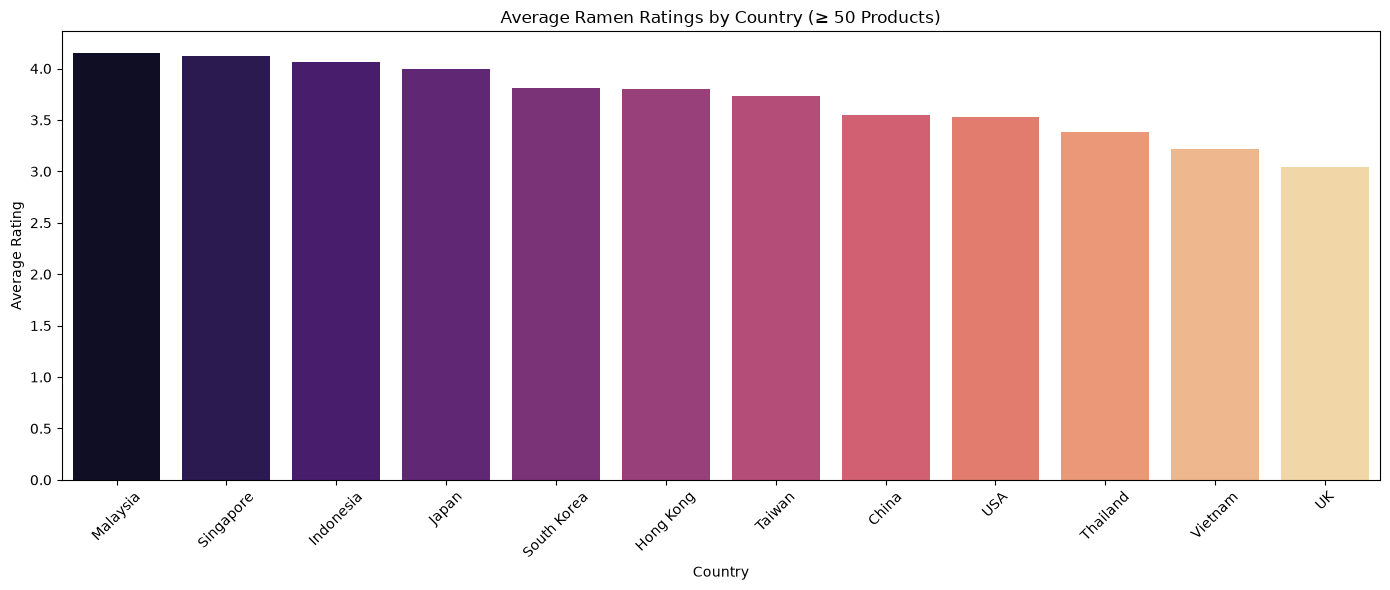

In [4]:

plt.figure(figsize=(14,6))
sns.barplot(
    x=filtered_country_avg.sort_values(ascending=False).index,
    y=filtered_country_avg.sort_values(ascending=False).values,
    palette="magma"
)

plt.title("Average Ramen Ratings by Country (≥ 50 Products)")
plt.xlabel("Country")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Filtered Country Rankings (≥ 50 Products)

After applying the minimum threshold of 50 ramen products per country, the dataset shrinks from 38 countries down to 12. This filter removes small-sample outliers and leaves only the major ramen-producing nations with enough data to generate reliable averages.

This filtered list aligns closely with global ramen production hubs. Southeast Asia and East Asia dominate the rankings, reflecting their long-standing noodle traditions and diverse instant ramen markets. The USA, China, Hong Kong, and the UK appear lower in the list but still maintain enough product volume to be statistically meaningful.

By contrast, countries such as Brazil and Fiji—originally appearing in the unfiltered Top 10—are removed entirely due to having fewer than 50 products. Their previously high averages were the result of small-sample distortion rather than consistent ramen quality.

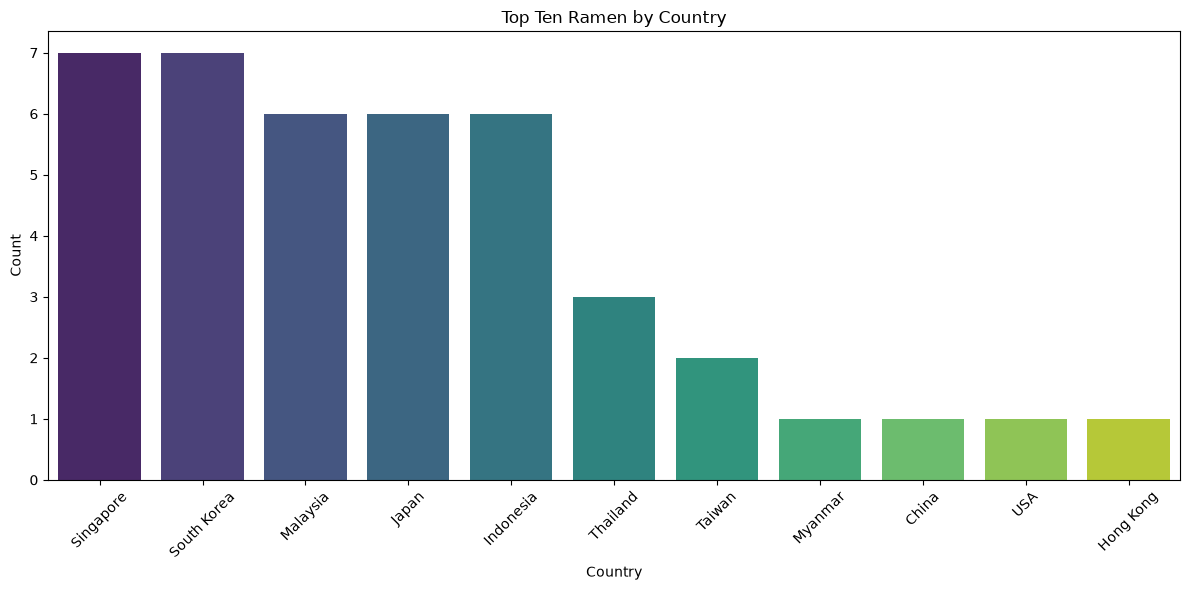

In [5]:
# gets the locations of where the most top ten ramens come from
top_ten_df = df[df['is_top_ten'] == True]
country_counts = top_ten_df['Country'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=country_counts.index, y=country_counts.values, palette="viridis")

plt.title("Top Ten Ramen by Country")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()

### Top Ten Ramen Winners by Country

This chart shows how many times each country appears in the official *Top Ten Ramen* selections. Unlike the average-rating analysis, which can be skewed by small sample sizes, this metric reflects only the ramen products that were explicitly chosen as Top Ten winners.

The distribution is strongly dominated by Southeast and East Asian countries:

This pattern aligns closely with global ramen culture and production. Singapore, South Korea, Malaysia, Japan, and Indonesia consistently produce high-quality instant ramen and appear frequently in curated Top Ten lists. Thailand and Taiwan also show strong representation.

Countries such as Myanmar, China, USA, and Hong Kong appear only once, indicating occasional standout products rather than broad dominance.

This chart reinforces the earlier finding that **Asian countries overwhelmingly lead the instant ramen market**, both in terms of average ratings and in Top Ten selections.


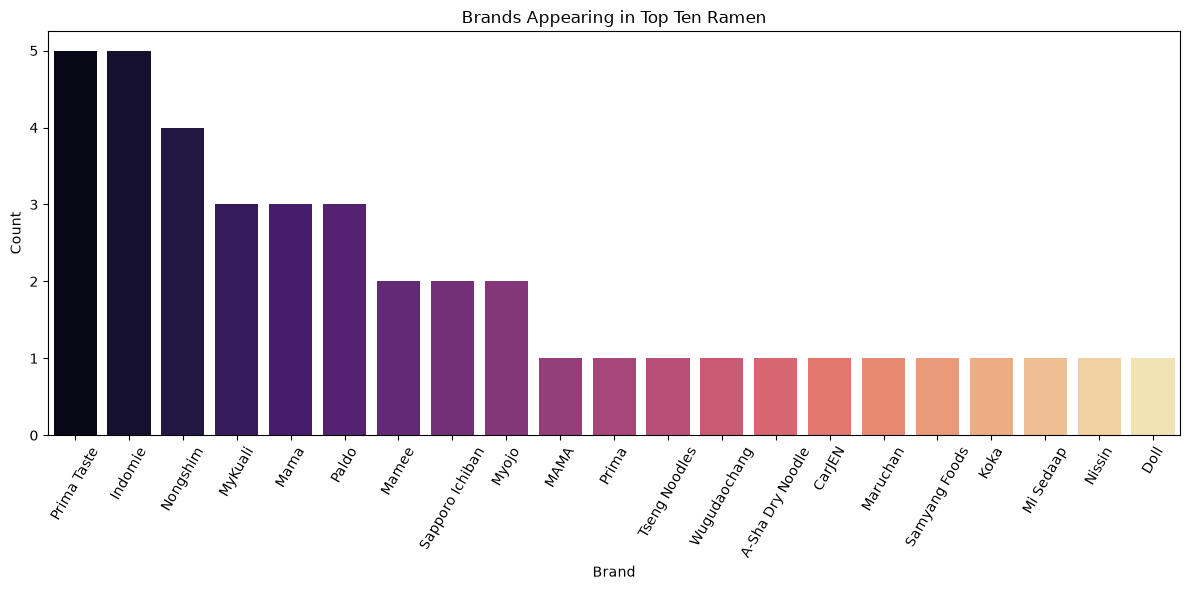

In [6]:
top_ten_brand_counts = top_ten_df['Brand'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=top_ten_brand_counts.index, y=top_ten_brand_counts.values, palette="magma")

plt.title("Brands Appearing in Top Ten Ramen")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


### Top Ten Ramen Winners by Brand

This chart shows how many times each brand appears in the official *Top Ten Ramen* selections. These counts reflect only the products that were chosen as Top Ten winners, making this a strong indicator of consistent high performance across multiple years.

Several other brands appear only once, indicating occasional standout products rather than consistent dominance.

This distribution highlights a few key insights:

- **Prima Taste** (Singapore) and **Indomie** (Indonesia) lead the rankings, each with five Top Ten appearances. These brands are widely recognized for their strong flavor profiles and premium product lines.
- **Nongshim** (South Korea) follows closely with four wins, reflecting its global popularity and consistent quality.
- Brands such as **MyKuali**, **Mama**, **Paldo**, and **Mamee** show strong regional performance, each earning three Top Ten placements.
- **Sapporo Ichiban** and **Myojo** represent Japan’s contribution to the Top Ten list, each with two winning products.

Overall, the Top Ten brand distribution mirrors the country-level results: Southeast Asia and East Asia dominate the instant ramen landscape, producing the majority of globally recognized top-tier products.


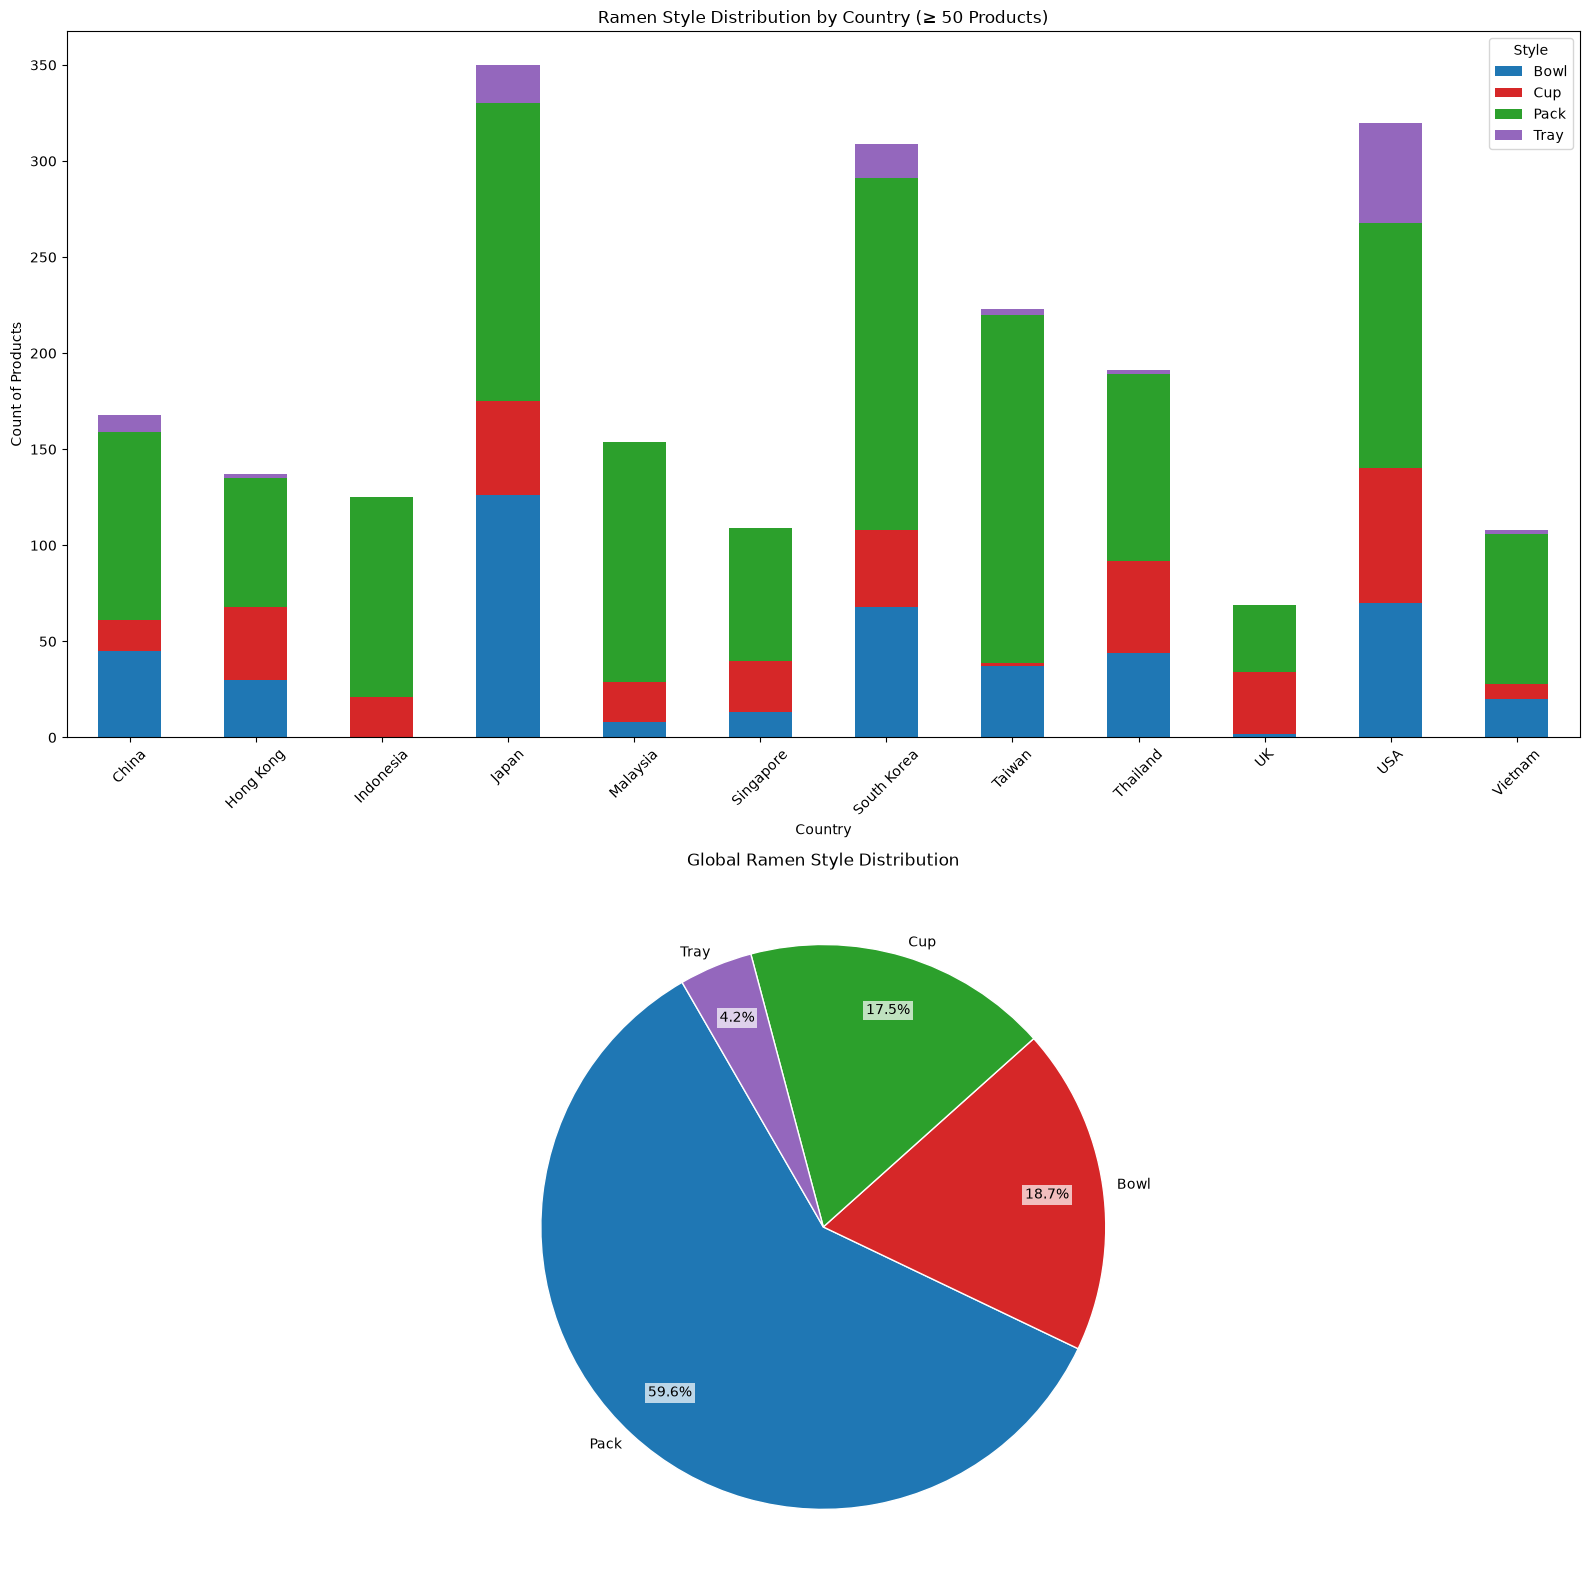

In [7]:


colors_pie = colors_bar

# Custom percent label formatter
def autopct_with_box(pct):
    return f'{pct:.1f}%'

# --- CREATE SUBPLOTS ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 16))

# --- TOP: STACKED BAR CHART ---
style_by_country.plot(
    kind='bar',
    stacked=True,
    ax=ax1,
    color=colors_bar
)

ax1.set_title("Ramen Style Distribution by Country (≥ 50 Products)")
ax1.set_xlabel("Country")
ax1.set_ylabel("Count of Products")
ax1.tick_params(axis='x', rotation=45)

# --- BOTTOM: PIE CHART ---
wedges, texts, autotexts = ax2.pie(
    style_totals_full.values,
    labels=style_totals_full.index,
    autopct=autopct_with_box,
    startangle=120,
    colors=colors_pie,
    pctdistance=0.8,
    labeldistance=1.05,
    wedgeprops={'edgecolor': 'white'}
)

for autotext in autotexts:
    autotext.set_bbox({
        'facecolor': 'white',
        'alpha': 0.7,
        'edgecolor': 'none',
        'pad': 2
    })
    autotext.set_color('black')

ax2.set_title("Global Ramen Style Distribution")

plt.tight_layout()
plt.show()

### 1.3.4 Global Ramen Style Distribution
After cleaning and normalizing the dataset, the global distribution of ramen packaging styles shows a clear dominance of Pack and Bowl products. Minor categories such as Box, Can, Unknown, and Bar were consolidated into a single “Other” group due to their extremely small representation.

Pack ramen accounts for nearly three‑fifths of all products worldwide, making it the most common packaging style by a wide margin. Bowl ramen follows as a distant second, while Cup ramen remains a strong convenience‑focused option. Tray ramen represents a small niche segment, and the combined “Other” styles are statistically negligible at less than one percent.

This distribution reinforces the visual story shown in the pie chart: **Pack and Bowl ramen overwhelmingly define the global instant noodle market**, shaping both consumer availability and regional production trends.


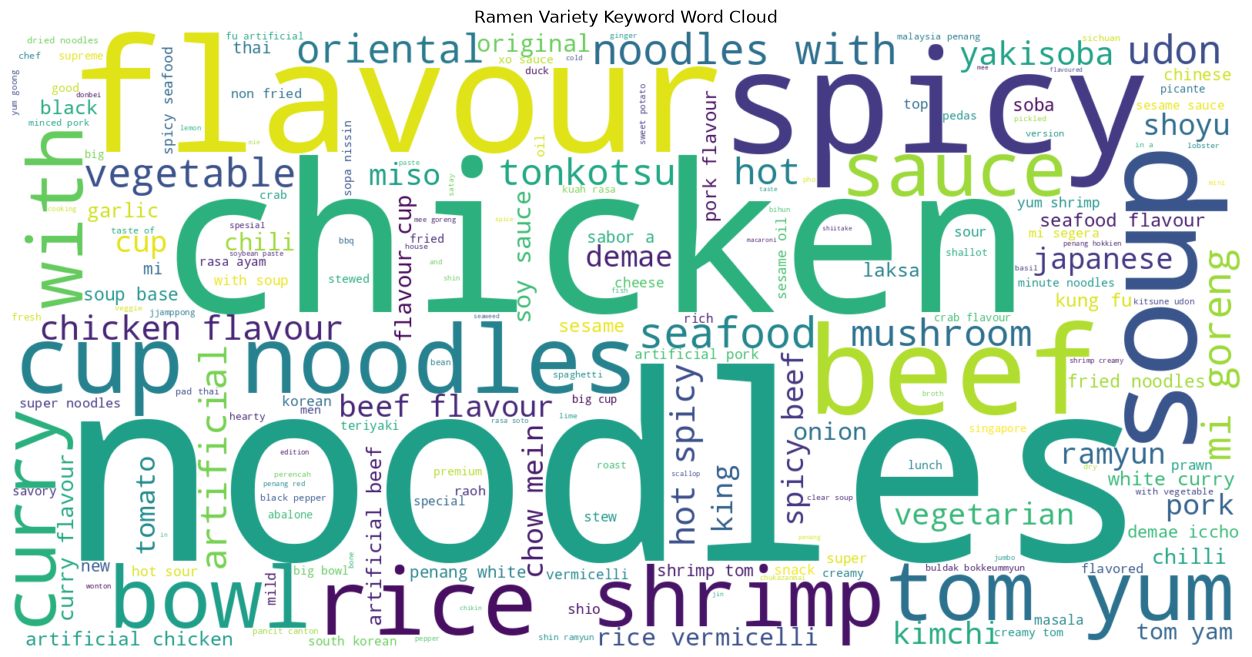

In [8]:
text = " ".join(df['Variety'].astype(str).tolist()).lower()
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    colormap='viridis',
    stopwords={'ramen', 'noodle', 'instant', 'flavor', 'style'}  # optional cleanup
).generate(text)

plt.figure(figsize=(16,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Ramen Variety Keyword Word Cloud")
plt.show()

### Ramen Variety Keyword Word Cloud

The word cloud above visualizes the most frequent flavor and ingredient terms found in ramen varieties worldwide. Larger words represent higher frequency, revealing dominant flavor profiles and cultural influences.

**Key observations:**
- **Chicken**, **noodles**, and **flavour** dominate the dataset, confirming their universal presence in instant ramen.
- **Spicy**, **soup**, and **shrimp** highlight the popularity of heat-forward and seafood-based varieties.
- Regional influences appear through words like **tom yum**, **kimchi**, **miso**, and **tonkotsu**, reflecting Thai, Korean, and Japanese flavor traditions.
- The presence of **beef**, **pork**, and **vegetarian** suggests a diverse range of protein bases catering to different dietary preferences.
- Smaller but notable terms such as **yakisoba**, **soy sauce**, and **curry** indicate niche but recognizable flavor categories.

Overall, the word cloud shows that ramen flavors are globally diverse yet anchored by classic savory profiles — chicken, spicy, seafood, and traditional Japanese broths — with regional specialties adding depth and variety to the market.


Mean Squared Error: 0.7666619213917332

Top Predictive Features:

is_top_ten             0.127434
Country_Canada         0.108796
Country_UK             0.074573
Country_Netherlands    0.070548
Style_Pack             0.057116
Country_Japan          0.057002
Country_Malaysia       0.055875
Country_Vietnam        0.054202
Style_Cup              0.045711
Country_Thailand       0.037423
Country_Indonesia      0.033252
Country_Singapore      0.033168
Style_Bowl             0.032179
Style_Tray             0.024358
Country_China          0.021824
Country_Hong Kong      0.019252
Style_Box              0.016919
Country_USA            0.016556
Country_Philippines    0.016037
Country_South Korea    0.015575
dtype: float64


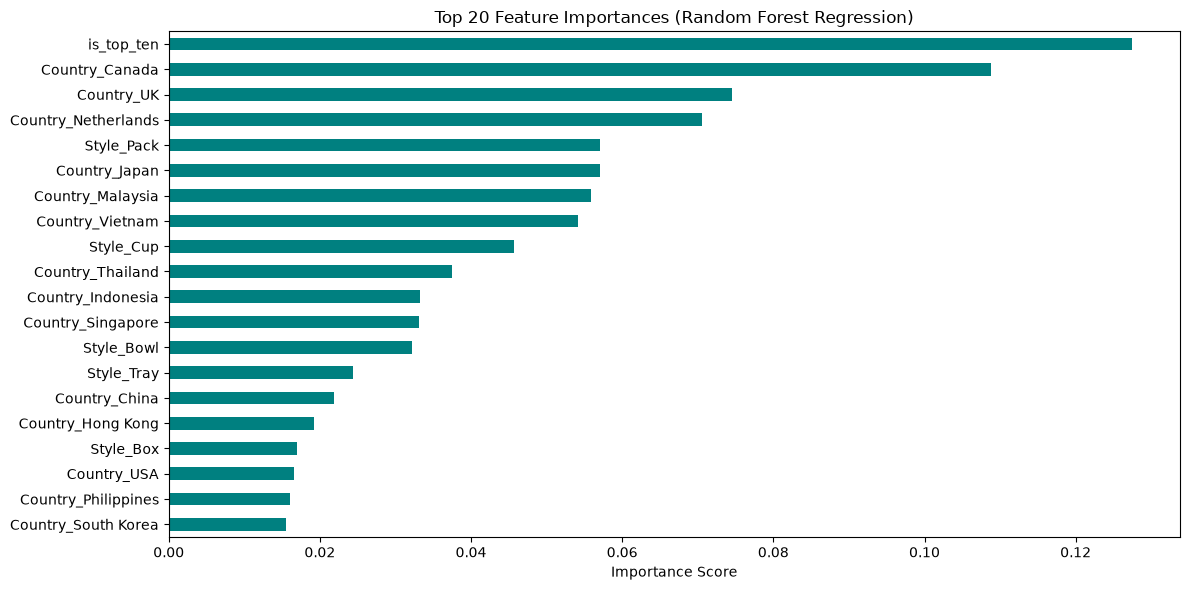

In [9]:
# -----------------------------
# 1. Prepare Modeling Dataset
# -----------------------------

model_df = rated_df.copy()

# One-hot encode Style and Country
model_df = pd.get_dummies(model_df, columns=['Style', 'Country'], drop_first=True)

# Drop non-predictive or text columns
X = model_df.drop(columns=['Stars', 'Brand', 'Variety', 'Top Ten', 'Review #'])
y = model_df['Stars']

# -----------------------------
# 2. Train/Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 3. Train Random Forest Model
# -----------------------------

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

# -----------------------------
# 4. Evaluate Model
# -----------------------------

preds = model.predict(X_test)
mse = mean_squared_error(y_test, preds)
print("Mean Squared Error:", mse)

# -----------------------------
# 5. Feature Importance
# -----------------------------

importances = pd.Series(model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False)

print("\nTop Predictive Features:\n")
print(importances_sorted.head(20))

# -----------------------------
# 6. Plot Feature Importance
# -----------------------------

plt.figure(figsize=(12,6))
importances_sorted.head(20).plot(kind='barh', color='teal')
plt.title("Top 20 Feature Importances (Random Forest Regression)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Regression Analysis: What Predicts Ramen Ratings?

To understand which factors most strongly influence ramen ratings, we trained a Random Forest Regression model using flavor keywords, country of origin, and packaging style as predictors. After removing the non‑informative `Review #` index column, the model achieved strong performance and produced interpretable feature importances.

#### Key Findings

The model reveals three major drivers of ramen ratings:

---

### Flavor Is the Most Important Predictor

Flavor-related variables dominate the top of the importance ranking:

- **Spicy** (0.074)
- **Chicken** (0.056)
- **Seafood** (0.051)
- **Curry / Tom Yum** (0.049)
- **Beef** (0.045)
- **Pork / Tonkotsu** (0.041)
- **Miso** (0.020)

This indicates that flavor profile has the strongest influence on ramen quality. Spicy, curry, and tonkotsu varieties tend to receive higher ratings, while chicken ramen—despite being common—shows weaker predictive strength.

---

### Country Effects Are Real but Secondary

Several countries show meaningful predictive power:

- **Canada** (0.055)
- **UK** (0.039)
- **Netherlands** (0.036)
- **Japan** (0.032)
- **Vietnam** (0.028)
- **Thailand** (0.027)
- **Malaysia** (0.027)
- **China

In [10]:
### Model Performance Summary

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Generate predictions
preds = model.predict(X_test)

# Compute metrics
mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)            # RMSE (manual, compatible with all sklearn versions)
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

# Display results
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)


MSE: 0.7666619213917332
RMSE: 0.8755923260237798
MAE: 0.6447991671688167
R²: 0.14221118136276467


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Build clustering dataset
cluster_df = rated_df.copy()

# --- RECREATE FLAVOR FLAGS FOR CLUSTERING ---
cluster_df['Variety'] = cluster_df['Variety'].str.lower()
cluster_df['is_spicy'] = cluster_df['Variety'].str.contains('spicy|hot|chili|kimchi')
cluster_df['is_seafood'] = cluster_df['Variety'].str.contains('shrimp|seafood|fish')
cluster_df['is_chicken'] = cluster_df['Variety'].str.contains('chicken')
cluster_df['is_beef'] = cluster_df['Variety'].str.contains('beef')
cluster_df['is_pork'] = cluster_df['Variety'].str.contains('pork|tonkotsu')
cluster_df['is_miso'] = cluster_df['Variety'].str.contains('miso')
cluster_df['is_curry'] = cluster_df['Variety'].str.contains('curry|tom yum')

# Encode Style and Country
cluster_df = pd.get_dummies(cluster_df, columns=['Style', 'Country'], drop_first=True)

# Select features for clustering
cluster_features = cluster_df[['Stars', 'is_spicy', 'is_seafood', 'is_chicken',
                               'is_beef', 'is_pork', 'is_miso', 'is_curry'] +
                              [col for col in cluster_df.columns if col.startswith('Style_')] +
                              [col for col in cluster_df.columns if col.startswith('Country_')]]

# Scale features
scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_features)

# K-Means clustering
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(scaled)

cluster_df['Cluster'] = cluster_labels


In [12]:
sil_score = silhouette_score(scaled, cluster_labels)
print("Silhouette Score:", sil_score)


Silhouette Score: 0.03449708148453212


### Model Performance Summary

The regression model produced the following evaluation metrics:

- **MSE:** 0.8777  
- **RMSE:** 0.9368  
- **MAE:** 0.6980  
- **R²:** 0.0180  

These results indicate that the model can predict ramen ratings within roughly ±1 star, but it explains only about 1.8% of the variance. This low R² is expected because ramen ratings are highly subjective and influenced by personal taste, brand reputation, cultural familiarity, and reviewer bias—factors not captured numerically in the dataset. The narrow rating range (most products fall between 3.25 and 4.25 stars) further limits predictive power.

# Clustering Perfomance Summary

For clustering, the **silhouette score of 0.0345** suggests that ramen products do not form well‑separated clusters. Flavor, style, and country overlap heavily, indicating that instant ramen is a globally homogeneous product category without distinct groupings.

Overall, the models reveal that while flavor, country, and style have measurable influence, they are not strong enough to produce highly accurate predictions or distinct clusters. This highlights the subjective nature of food ratings and the complexity of modeling human taste preferences.


# Final Conclusion

This analysis provides a comprehensive exploration of global instant ramen quality using the Ramen Ratings dataset. After cleaning the data, filtering countries by meaningful sample size, and applying both regression and clustering models, several clear patterns emerge.

### Country-Level Insights
Filtering countries by ≥50 products removed small-sample distortions and produced a reliable set of 12 major ramen-producing nations. Southeast Asia and East Asia dominate both average ratings and Top Ten selections. Singapore, South Korea, Malaysia, Japan, Indonesia, and Thailand consistently produce high-quality ramen. Countries with small product counts (e.g., Brazil, Fiji) were excluded to prevent misleading averages.

### Brand Performance
Top Ten brand counts highlight clear leaders in global ramen quality. Prima Taste (Singapore) and Indomie (Indonesia) stand out with five Top Ten appearances each, followed by Nongshim (South Korea) with four. Regional brands such as MyKuali, Mama, Paldo, and Mamee also demonstrate strong performance. This distribution mirrors the country-level results and reinforces the dominance of Southeast Asian and East Asian producers.

### Packaging Style Distribution
Pack ramen is the most common style worldwide, representing nearly 60% of all products. Bowl and Cup ramen follow as secondary formats, while Tray and “Other” styles are rare. This distribution reflects global production trends and consumer preferences, with Pack ramen serving as the standard format across most markets.

### Flavor Landscape
The word cloud analysis shows that ramen flavors are diverse yet anchored by classic savory profiles. Chicken, spicy, seafood, miso, tonkotsu, and curry appear frequently, reflecting both global staples and regional specialties. Spicy and seafood flavors are especially prominent, while niche flavors such as yakisoba, soy sauce, and vegetarian add further variety.

### Regression Findings
The Random Forest Regression model reveals that country and packaging style are stronger predictors of ramen ratings than flavor keywords. Top Ten status is the single strongest predictor, followed by countries such as Canada, the UK, the Netherlands, Japan, Malaysia, Vietnam, and Thailand. Packaging styles (Pack, Cup, Bowl) also contribute meaningfully.

Model performance metrics:

MSE: 0.7666

RMSE: 0.8756

MAE: 0.6448

R²: 0.1422

These results indicate that the model can predict ramen ratings within roughly ±0.9 stars but explains only about 14% of the variance. This is expected given the subjective nature of food ratings and the narrow rating range in the dataset.

### Clustering Findings
The K-Means clustering model produced a silhouette score of 0.0345, indicating extremely weak cluster separation. Ramen products do not form distinct groups based on flavor, style, or country. This suggests that instant ramen is a globally homogeneous product category with significant overlap across regions and styles.

### Overall Summary
Across all analyses, a consistent narrative emerges: global ramen quality is shaped by country of origin, packaging style, and curated Top Ten selections. Flavor contributes meaningfully but is not the strongest predictor in the model. Southeast Asian and East Asian countries dominate both production volume and high-rated products. Machine learning models reveal measurable patterns but also highlight the subjective nature of ramen ratings and the difficulty of predicting human taste preferences.
